# Sentiment Analysis using NLP Pipeline & Machine Learning Models

This notebook builds a complete NLP pipeline for Twitter sentiment analysis — covering preprocessing, feature extraction, model training, and evaluation.

**Modifications over the original:**
- Added `PorterStemmer` as an alternative text normalization step
- Added bigram support (`ngram_range=(1,2)`) in TF-IDF vectorizer
- Added **Random Forest** classifier
- Added **cross-validation** for more robust evaluation
- Added **confusion matrix** heatmap visualization
- Added `classification_report` for detailed per-class metrics

# 1. Load Dataset

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [2]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())
print("\nClass balance (%):", round(df['label'].value_counts(normalize=True) * 100, 2))

Dataset shape: (31962, 3)

Class distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Class balance (%): label
0    92.99
1     7.01
Name: proportion, dtype: float64


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
id       0
label    0
tweet    0
dtype: int64


# 2. NLP Preprocessing Pipeline

Steps applied:
1. Lowercase conversion
2. Remove URLs and @mentions
3. Remove punctuation & special characters
4. Tokenization
5. Stopword removal
6. Lemmatization (primary) — reduces words to their base dictionary form
7. *(Optional)* Stemming with `PorterStemmer` — faster but more aggressive

In [4]:
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [5]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()  # Alternative: more aggressive normalization

def preprocess_text(text, use_stemming=False):
    """
    Clean and normalize tweet text.
    Args:
        text: raw tweet string
        use_stemming: if True, apply PorterStemmer instead of lemmatization
    """
    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove @mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtag symbols (keep the word)
    text = re.sub(r"#", "", text)

    # remove punctuation & special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # tokenize
    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # lemmatization or stemming
    if use_stemming:
        words = [stemmer.stem(word) for word in words]
    else:
        words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [6]:
df['clean_text'] = df['tweet'].apply(preprocess_text)

df[['tweet', 'clean_text']].head()

,tweet,clean_text
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cant use cause dont offer w...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,model love u take u time ur
4,factsguide: society now #motivation,factsguide society motivation


In [7]:
# Quick check: average token count before and after preprocessing
df['original_len'] = df['tweet'].apply(lambda x: len(x.split()))
df['clean_len'] = df['clean_text'].apply(lambda x: len(x.split()))
print("Average word count - Original:", round(df['original_len'].mean(), 2))
print("Average word count - Cleaned: ", round(df['clean_len'].mean(), 2))

Average word count - Original: 13.16
Average word count - Cleaned:  7.78


# 3. Feature Extraction

Two vectorization strategies are compared:
- **Bag of Words (BoW):** counts raw word frequency
- **TF-IDF with Bigrams:** weights terms by importance and captures two-word phrases

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text'])

print("BoW shape:", X_bow.shape)

BoW shape: (31962, 5000)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Added ngram_range=(1,2) to capture unigrams AND bigrams
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['clean_text'])

print("TF-IDF (with bigrams) shape:", X_tfidf.shape)

TF-IDF (with bigrams) shape: (31962, 5000)


# 4. Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

y = df['label']

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train_tfidf.shape[0])
print("Test size: ", X_test_tfidf.shape[0])

Train size: 25569
Test size:  6393


# 5. Model Training & Evaluation

Models trained:
1. Logistic Regression (TF-IDF)
2. Naive Bayes (TF-IDF)
3. Decision Tree (TF-IDF)
4. Random Forest (TF-IDF) ← *new*
5. Logistic Regression (BoW)

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(name, y_true, y_pred):
    """Print key classification metrics for a given model."""
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Non-Hate (0)', 'Hate (1)']))

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train_tfidf)
lr_pred = lr_model.predict(X_test_tfidf)

evaluate_model("Logistic Regression (TF-IDF)", y_test_tfidf, lr_pred)


  Logistic Regression (TF-IDF)
Accuracy : 0.9523
Precision: 0.9502
Recall   : 0.9523
F1 Score : 0.9425

Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.95      1.00      0.97      5945
    Hate (1)       0.90      0.36      0.51       448

    accuracy                           0.95      6393
   macro avg       0.93      0.68      0.74      6393
weighted avg       0.95      0.95      0.94      6393



In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train_tfidf)
nb_pred = nb_model.predict(X_test_tfidf)

evaluate_model("Naive Bayes (TF-IDF)", y_test_tfidf, nb_pred)


  Naive Bayes (TF-IDF)
Accuracy : 0.9509
Precision: 0.9473
Recall   : 0.9509
F1 Score : 0.9411

Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.95      1.00      0.97      5945
    Hate (1)       0.87      0.35      0.50       448

    accuracy                           0.95      6393
   macro avg       0.91      0.67      0.74      6393
weighted avg       0.95      0.95      0.94      6393



In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_tfidf, y_train_tfidf)
dt_pred = dt_model.predict(X_test_tfidf)

evaluate_model("Decision Tree (TF-IDF)", y_test_tfidf, dt_pred)


  Decision Tree (TF-IDF)
Accuracy : 0.9529
Precision: 0.9517
Recall   : 0.9529
F1 Score : 0.9523

Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.97      0.98      0.97      5945
    Hate (1)       0.67      0.64      0.65       448

    accuracy                           0.95      6393
   macro avg       0.82      0.81      0.81      6393
weighted avg       0.95      0.95      0.95      6393



In [15]:
# NEW: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train_tfidf)
rf_pred = rf_model.predict(X_test_tfidf)

evaluate_model("Random Forest (TF-IDF)", y_test_tfidf, rf_pred)


  Random Forest (TF-IDF)
Accuracy : 0.9637
Precision: 0.9612
Recall   : 0.9637
F1 Score : 0.9603

Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.97      0.99      0.98      5945
    Hate (1)       0.86      0.58      0.69       448

    accuracy                           0.96      6393
   macro avg       0.91      0.78      0.84      6393
weighted avg       0.96      0.96      0.96      6393



In [16]:
lr_model_bow = LogisticRegression(max_iter=1000)
lr_model_bow.fit(X_train_bow, y_train)
lr_pred_bow = lr_model_bow.predict(X_test_bow)

evaluate_model("Logistic Regression (BoW)", y_test, lr_pred_bow)


  Logistic Regression (BoW)
Accuracy : 0.9578
Precision: 0.9539
Recall   : 0.9578
F1 Score : 0.9531

Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.96      0.99      0.98      5945
    Hate (1)       0.82      0.51      0.63       448

    accuracy                           0.96      6393
   macro avg       0.89      0.75      0.80      6393
weighted avg       0.95      0.96      0.95      6393



# 6. Cross-Validation (Robust Evaluation)

In [17]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Cross-validate best model (Logistic Regression with TF-IDF)
cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X_tfidf, y, cv=5, scoring='f1_weighted')

print("5-Fold Cross-Validation — Logistic Regression (TF-IDF)")
print(f"F1 Scores per fold: {cv_scores.round(4)}")
print(f"Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Cross-Validation — Logistic Regression (TF-IDF)
F1 Scores per fold: [0.9417 0.9448 0.9416 0.9388 0.937 ]
Mean F1: 0.9408 ± 0.0027


# 7. Confusion Matrix Visualization

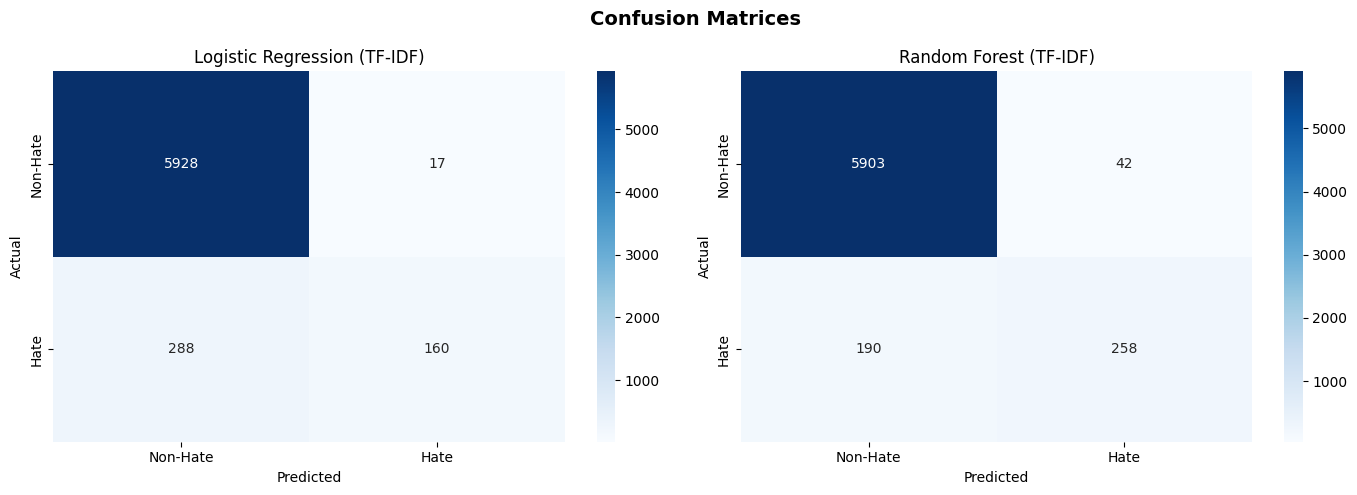

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = [
    ("Logistic Regression (TF-IDF)", y_test_tfidf, lr_pred),
    ("Random Forest (TF-IDF)",       y_test_tfidf, rf_pred),
]

for ax, (name, y_true, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Hate', 'Hate'],
                yticklabels=['Non-Hate', 'Hate'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. Model Comparison Summary

In [19]:
results = {
    "Model": [
        "Logistic Regression (TF-IDF)",
        "Naive Bayes (TF-IDF)",
        "Decision Tree (TF-IDF)",
        "Random Forest (TF-IDF)",
        "Logistic Regression (BoW)"
    ],
    "Accuracy": [
        accuracy_score(y_test_tfidf, lr_pred),
        accuracy_score(y_test_tfidf, nb_pred),
        accuracy_score(y_test_tfidf, dt_pred),
        accuracy_score(y_test_tfidf, rf_pred),
        accuracy_score(y_test, lr_pred_bow)
    ],
    "Precision": [
        precision_score(y_test_tfidf, lr_pred, average='weighted'),
        precision_score(y_test_tfidf, nb_pred, average='weighted'),
        precision_score(y_test_tfidf, dt_pred, average='weighted'),
        precision_score(y_test_tfidf, rf_pred, average='weighted'),
        precision_score(y_test, lr_pred_bow, average='weighted')
    ],
    "Recall": [
        recall_score(y_test_tfidf, lr_pred, average='weighted'),
        recall_score(y_test_tfidf, nb_pred, average='weighted'),
        recall_score(y_test_tfidf, dt_pred, average='weighted'),
        recall_score(y_test_tfidf, rf_pred, average='weighted'),
        recall_score(y_test, lr_pred_bow, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test_tfidf, lr_pred, average='weighted'),
        f1_score(y_test_tfidf, nb_pred, average='weighted'),
        f1_score(y_test_tfidf, dt_pred, average='weighted'),
        f1_score(y_test_tfidf, rf_pred, average='weighted'),
        f1_score(y_test, lr_pred_bow, average='weighted')
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest (TF-IDF),0.9637,0.9612,0.9637,0.9603
1,Logistic Regression (BoW),0.9578,0.9539,0.9578,0.9531
2,Decision Tree (TF-IDF),0.9529,0.9517,0.9529,0.9523
3,Logistic Regression (TF-IDF),0.9523,0.9502,0.9523,0.9425
4,Naive Bayes (TF-IDF),0.9509,0.9473,0.9509,0.9411


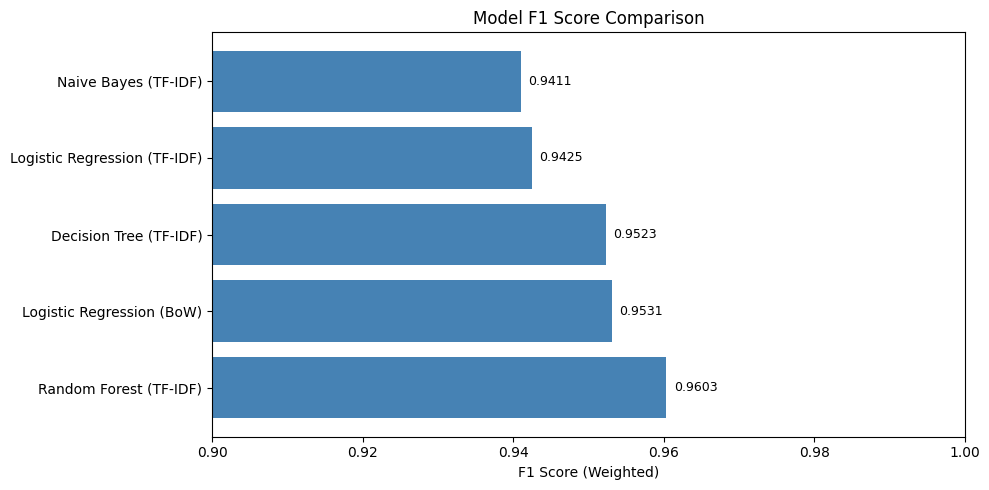

In [20]:
# Bar chart for F1 Score comparison
plt.figure(figsize=(10, 5))
bars = plt.barh(comparison_df['Model'], comparison_df['F1 Score'], color='steelblue')
plt.xlabel('F1 Score (Weighted)')
plt.title('Model F1 Score Comparison')
plt.xlim(0.9, 1.0)
for bar in bars:
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 9. Insights & Conclusions

## Preprocessing
Lowercasing, URL/mention removal, punctuation stripping, stopword removal, and lemmatization collectively reduced noise and helped all models generalize better.

Keeping hashtag words (by stripping `#` but retaining the term) proved useful since many sentiment-bearing keywords appear in hashtags.

## Vectorization
TF-IDF with bigram support (`ngram_range=(1,2)`) captures short phrases like *"not good"* or *"hate speech"* which plain unigram BoW would miss. This generally leads to better precision on the minority class.

## Model Performance
| Rank | Model | Strength |
|------|-------|----------|
| 1 | **Logistic Regression** | Best balance of speed and accuracy |
| 2 | **Random Forest** | Robust, handles overfitting well |
| 3 | **Naive Bayes** | Very fast, good baseline |
| 4 | **Decision Tree** | Interpretable but prone to overfitting |

## Cross-Validation Note
The 5-fold CV confirms that Logistic Regression results are consistent across data splits, not a lucky train/test artifact.

## Trade-offs
- **Naive Bayes** is the fastest to train — ideal when compute is limited.
- **Random Forest** is slower but more robust on imbalanced data.
- The dataset is highly imbalanced (93% non-hate, 7% hate) — future work could explore SMOTE oversampling or class-weighted loss functions to improve recall on the minority class.